<b> Nom étudiant </b> : AMETOVENA Kodjo Elom Ezéchiel

###  1.Introduction sur la thématique

La dégradation des écosystèmes forestiers constitue un des enjeux majeurs au
Togo (pays situé en Afrique de l’ouest). Face à cette situation, plusieurs actions de restauration forestière telles que la plantation et les sensibilisations sont mises en œuvre par une diversité d’acteurs (ONG, entreprises, collectivités locales, acteurs para-publics).

Cependant, le suivi de ces actions reste souvent fragmenté, avec des données dispersées, hétérogènes et difficilement exploitables dans le temps. La mise en place d’un observatoire de suivi des activités de restauration forestière, basée sur des données géographiques structurées, permettrait de centraliser l’information, de suivre l’évolution des actions par rapport à une situation de référence (baseline) et d’évaluer l’atteinte des objectifs fixés (cibles) sur la durée du projet.

L’objectif de ce travail est donc de concevoir et d’implémenter une base de donnée relationnelle sous PostgreSQL/PostGIS, permettant de suivre, analyser et cartographier les activités de restauration forestière sur toute l’étendue du territoire togolais.

### 2. Description des données et présentation du modèle de données

Cette  base de données comporte à la fois des  données spatiales et non spatiales. Les sources de ces données sont mentionnées à l'annexe 2 de ce document.

##### 2.1. Données non spatiales

<ul>
  <li>
    <strong>Table acteur</strong><br>
    Cette table contient les informations relatives aux acteurs impliqués dans le projet de restauration forestière.
    <ul>
      <li> <i> idacteur </i> : Identifiant unique de l'acteur (clé primaire)</li>
      <li> <i> nomacteur  </i> : Nom de l'acteur </li>
      <li> <i> typeacteur </i> : Catégorie de l'acteur (ONG, entreprise, etc..) </li>
      <li> <i> contact_tel  </i> : Numéro de téléphone de l'acteur (format fixe de 12 caractères) </li>
      <li> <i> contactemail </i> : Adresse email  de l'acteur </li>
    </ul>
  </li>

  <li>
    <strong>Table typeactivite</strong><br>
    Elle renferme les informations portant sur les types d'activité. Dans la modélisation de la base de données, elle est considérée comme super classe ou surtype. Cette table possède donc des sous classes ou sous-type (plantation, entretien, sensibilisation) qui seront présenté dans la suite de ce document. Elle ne comporte que les informations qui sont communes à ces trois tables sous-type mentionnées ci-dessus.
    <ul>
      <li> <i> idtacti  </i> : Identifiant unique de l'activité (clé primaire)</li>
      <li> <i> nom   </i> : Nom de l'activité </li>
      <li> <i> categorie  </i> : Catégorie d'activité (Plantation pour catégorie restauration, enntretien pour catégorie maintien, sensibilisation pour catégorie activité sociale) </li>
      </ul>
  </li>

   <li>
    <strong>Table plantation</strong><br>
    Elle renferme les informations portant sur les activités de type plantation. Elle  comporte  les attributs ci-dessous.
    <ul>
      <li> <i> idplantation  </i> : Identifiant unique de l'activité de type plantation (clé primaire)</li>
      <li> <i> nomplantation    </i> :Description de l'opération de plantation </li>
      <li> <i> idtacti   </i> : Clé de référence au type d'activité (clé étrangère vers la table typeactivite) </li>
      </ul>
  </li>

  <li>
    <strong>Table entretien</strong><br>
    Elle renferme les informations portant sur les activités de type entretien. Elle  comporte  les attributs ci-dessous.
    <ul>
      <li> <i> identretien   </i> : Identifiant unique de l'activité de type entretien (clé primaire)</li>
      <li> <i> typeentretien  </i> : Typologie de l'opération de plantation (arrosage, fertilisation, etc..) </li>
      <li> <i> idtacti   </i> : Clé de référence au type d'activité (clé étrangère vers la table typeactivite) </li>
    </ul>
  </li>

  <li>
    <strong>Table sensibilisation</strong><br>
    Elle renferme les informations portant sur les activités de type sensibilisation. Elle  comporte  les attributs ci-dessous:
    <ul>
      <li> <i> idsens  </i> : Identifiant unique de l'activité de type sensibilisation (clé primaire)</li>
      <li> <i> nbparticipant </i> : Nombre de participant </li>
      <li> <i> satisfaction  </i> : Niveau de satisfaction des participants (faible, moyen, élevé) </li>
      <li> <i> idtacti   </i> : Clé de référence au type d'activité (clé étrangère vers la table typeactivite) </li>
      <li> <i> idlocalite   </i> : Clé de référence à la localité où s'est déroulée la sensibilisation (clé étrangère vers la table localite) </li>
    </ul>
  </li>

  <u> NB: Il est à noté que les activités de plantation se déroulent directement dans une zone de plantation alors que l'activité de sensibilisation se déroule dans une localité </u>

  <li>
    <strong>Table espece</strong><br>
    Cette table informe sur les espèce utilisés pour effectuer les activités de type planatation. Ses attributs sont les suivants:
    <ul>
      <li> <i> idespece </i> : Identifiant unique de l'espèce (clé primaire)</li>
      <li> <i> codespece </i> : Code de l'espèce </li>
      <li> <i> nomscientifique </i> : Nom scientifique de l'espèce </li>
      <li> <i> nomvernaculaire </i> : Nom de l'espèce en langue locale  </li>
      <li> <i> famille</i> : Famille d'appartenance de l'espèce</li>
    </ul>
  </li>

  <li>
    <strong>Table realisation </strong><br>
    Elle renferme les informations portant sur la réalisation ou l'éxécution des activités. On peut dire que c'est la table centrale de cette base de données. Elle  comporte  les attributs ci-dessous:
    <ul>
      <li> <i> idrealisation </i> : Identifiant unique de chaque réalisation (clé primaire)</li>
      <li> <i> daterealisation  </i> : Date de réalisation des activités </li>
      <li> <i> valeurealise   </i> : Valeur réalisée </li>
      <li> <i> idzone    </i> : Clé de référence à la zone de plantation (clé étrangère vers la table zoneplantation) </li>
      <li> <i> idindic    </i> : Clé de référence à l'indicateur qui mésure la réalisation (clé étrangère vers la table indicateur) </li>
      <li> <i> idtacti   </i> : Clé de référence au type d'activité (clé étrangère vers la table typeactivite) </li>
    </ul>
  </li>

   <li>
    <strong>Table indicateur </strong><br>
   Cette table informe sur les indicateurs de mésure des activités. Ses attributs sont les suivants:
    <ul>
      <li> <i> idindic  </i> : Identifiant unique de chaque indicateur (clé primaire)</li>
      <li> <i> nomindic </i> : Nom de l'indicateur</li>
      <li> <i> descriptionindic </i> : Description de l'indicateur </li>
      <li> <i> typeindic     </i> : Type d'indicateur  (qualitatif, quantitatif, etc... ) </li>
    </ul>
  </li>

  <li>
    <strong>Table baseline </strong><br>
    Elle renferme les informations  sur la situation de référence c'est à dire  les valeurs de référence initiales avant intervention. Elle  comporte  les attributs ci-dessous:
    <ul>
      <li> <i> idbaseline  </i> : Identifiant unique de chaque baseline  (clé primaire)</li>
      <li> <i> valeurbase   </i> : Valeur initiale </li>
      <li> <i> datereference   </i> : Date de la mesure de référence </li>
      <li> <i> idindic    </i> : Clé de référence à l'indicateur  (clé étrangère vers la table indicateur) </li>
      <li> <i> idsite   </i> : Clé de référence au site (clé étrangère vers la table sitearestaurer) </li>
    </ul>
  </li>

  <li>
    <strong>Table cible </strong><br>
    Elle renferme les informations  sur les objectifs à atteindre pour chaque indicateur. Ci-dessous ses attributs:
    <ul>
      <li> <i> idcible   </i> : Identifiant unique de chaque cible  (clé primaire)</li>
      <li> <i> valeurcible   </i> : Valeur cible </li>
      <li> <i> anneecible    </i> : Année pour laquelle la cible doit être atteinte </li>
      <li> <i> idindic    </i> : Clé de référence à l'indicateur  (clé étrangère vers la table indicateur) </li>
      <li> <i> idsite   </i> : Clé de référence au site (clé étrangère vers la table sitearestaurer) </li>
    </ul>
  </li>

  <li>
    <strong>Table effectuer</strong><br>
    Elle repertorie le rôle (éxécutant, superviseur) d'un acteur  sur chacune des réalisations. Ci-dessous ses attributs:
    <ul>
      <li> <i> idacteur,idrealisation  </i> : Concaténation des identifiants des tables realisation et acteur servant de clé primaire pour la table effectuer  (clé primaire)</li>
      <li> <i> role   </i> : le rôle (éxécutant, superviseur) d'un acteur  sur chacune des réalisations </li>
      <li> <i> idacteur    </i> : Clé de référence à l'acteur  (clé étrangère vers la table acteur) </li>
      <li> <i> idrealisation   </i> : Clé de référence à la réalisation (clé étrangère vers la table realisation) </li>
    </ul>
  </li>

  <li>
    <strong>Table utiliser</strong><br>
    Cette table repertorie la quantité d'espèce utilisé pour les activités de plantations. Elle  comporte  les attributs ci-dessous:
    <ul>
      <li> <i> idplantation,idespece   </i> : Concaténation des identifiants des tables plantation et espèce servant de clé primaire pour la table utiliser (clé primaire)</li>
      <li> <i> quantité   </i> : la quantité d'espèce utilisé pour les activités de plantations </li>
      <li> <i> idplantation </i> : Clé de référence aux plantations  (clé étrangère vers la table plantation) </li>
      <li> <i> idespece </i> : Clé de référence aux espèces (clé étrangère vers la table espece) </li>
    </ul>
  </li>

  <li>
    <strong> Table rattacher </strong><br>
    La table rattacher est créee du point  de vu conceptuel au vu  des cardinalités entre les tables localite et sitearestaurer. Elle comporte donc les clés primaires de ces tables en tant que clé étrangère:
    <ul>
      <li> <i> idsite,idlocalite    </i> : Concaténation des identifiants des tables localite et sitearestaurer servant de clé primaire pour la table rattacher (clé primaire)</li>
      <li> <i> idsite </i> : Clé de référence aux site à restaurer  (clé étrangère vers la table sitearestaurer) </li>
      <li> <i> idlocalite  </i> : Clé de référence aux localités (clé étrangère vers la table localite) </li>
    </ul>
  </li>

  <li>
    <strong> Table se_trouver </strong><br>
    La table se_trouver est créee également du point de vu conceptuel au vu  des cardinalités entre les tables aire_protege et localite. Elle comporte donc les clés primaires de ces tables en tant que clé étrangère:
    <ul>
      <li> <i> idap,idlocalite    </i> : Concaténation des identifiants des tables localite et aire_protege servant de clé primaire pour la table se_trouver (clé primaire)</li>
      <li> <i> idap </i> : Clé de référence aux aires protégées  (clé étrangère vers la table aire_protege) </li>
      <li> <i> idlocalite  </i> : Clé de référence aux localités (clé étrangère vers la table localite) </li>
    </ul>
  </li>

  <u> Les tables se_trouver, rattacher et  utiliser sont des associations dans le modèle conceptuel de  données devenues  des tables dans le modèle logique de données </u>
</ul>


##### 2.2. Données  spatiales

<ul>
  <li>
    <strong>Table region </strong><br>
    Cette table (couche) renseigne sur les régions administratives du Togo.
    <ul>
      <li> <i> idregion  </i> : Identifiant unique de chaque région (clé primaire)</li>
      <li> <i> nomregion   </i> : Nom de la région </li>
      <li> <i> geom  </i> :Contour géographique de la région (en EPSG 32631, type de geom: POLYGON) </li>
    </ul>
  </li>

  <li>
    <strong>Table commune </strong><br>
    Comme l'indique son nom, cette couche renseigne sur les communes  du Togo.
    <ul>
      <li> <i> idcommune   </i> : Identifiant unique de chaque commune (clé primaire)</li>
      <li> <i> nomcommune    </i> : Nom de la commune </li>
      <li> <i> geom  </i> : Contour géographique de la commune (en EPSG 32631, type de geom: POLYGON) </li>
      <li> <i> idregion    </i> : Clé de référence à la région (clé étrangère vers la table region) </li>
    </ul>
  </li>

  <li>
    <strong>Table localite </strong><br>
    Cette couche renseigne sur les localités (village, hameau, ville)  du Togo.
    <ul>
      <li> <i> idlocalite    </i> : Identifiant unique de chaque localité (clé primaire)</li>
      <li> <i> nomlocalite     </i> : Nom de la localité </li>
      <li> <i> geom  </i> : Coordonnées géographiques da la localité (en EPSG 32631, type de geom: POINT) </li>
      <li> <i> idcommune     </i> : Clé de référence à la commune (clé étrangère vers la table commune) </li>
    </ul>
  </li>

  <li>
    <strong>Table zoneplantation </strong><br>
    Il s'agit des zones (périmètre) sur lesquelles se sont effectuées les activités de plantation.
    <ul>
      <li> <i> idzone </i> : Identifiant unique de chaque zone de plantation (clé primaire)</li>
      <li> <i> nomzone      </i> : Nom de la zone </li>
      <li> <i> geom  </i> :Contour géographique de la zone de plantation (en EPSG 32631, type de geom: POLYGON) </li>
      <li> <i> idsite </i> : Clé de référence aiu site (clé étrangère vers la table sitearestaurer) </li>
    </ul>
  </li>

  <li>
    <strong>Table sitearestaurer </strong><br>
    Cette couche définit les périmètres autorisés pour les activités de plantation. Toute activité de plantation doit obligatoirement se dérouler à l’intérieur de ces périmètres.
    <ul>
      <li> <i> idsite  </i> : Identifiant unique de chaque site à restaurer (clé primaire)</li>
      <li> <i> nomsite  </i> : Nom du site </li>
      <li> <i> geom  </i> :Contour géographique du site à restaurer(en EPSG 32631, type de geom: POLYGON) </li>
    </ul>
  </li>

  <li>
    <strong>Table aire_protege </strong><br>
    Il s'agit de la couche qui renferme les aires protégées.
    <ul>
      <li> <i> idap </i> : Identifiant unique de chaque aire protégée (clé primaire)</li>
      <li> <i> nomap </i> : Nom de l'aire protégée </li>
      <li> <i> datecreationap </i> : Date de création de l'aire protégée </li>
      <li> <i> superficieap_ha   </i> : Superficie de l'aire protégée en hectare </li>
      <li> <i> geom </i> :Contour géographique de l'aire protégée (en EPSG 32631, type de geom: POLYGON) </li>
    </ul>
  </li>
</ul>

### 3. Un exemple de requête permettant d’extraire des données de la base

La requête ci-dessous effetue la somme des réalisations par zone de plantation.

In [ ]:

CREATE VIEW vue_zones_realisation_centroid AS
SELECT
    z.idzone AS id,
    s.idsite,
    ST_Centroid(z.geom) AS geom,
    z.nomzone,
    COUNT(r.idrealisation) AS nb_realisation,
    SUM(r.valeurealise::numeric) AS total_realise,
    CASE
        WHEN SUM(r.valeurealise::numeric) IS NULL THEN 'Aucune réalisation'
        WHEN SUM(r.valeurealise::numeric) >= 200 AND SUM(r.valeurealise::numeric) < 6000 THEN 'Faible'
        WHEN SUM(r.valeurealise::numeric) >= 6000 AND SUM(r.valeurealise::numeric) < 7000 THEN 'Moyen'
        WHEN SUM(r.valeurealise::numeric) >= 7000 THEN 'Élevé'
    END AS classement_realisation
FROM zoneplantation z
LEFT JOIN realisation r ON z.idzone = r.idzone
JOIN sitearestaurer s ON z.idsite = s.idsite
GROUP BY z.idzone, z.nomzone, s.idsite, z.geom;

### 4. Résultat de la précédente requête sous forme de carte

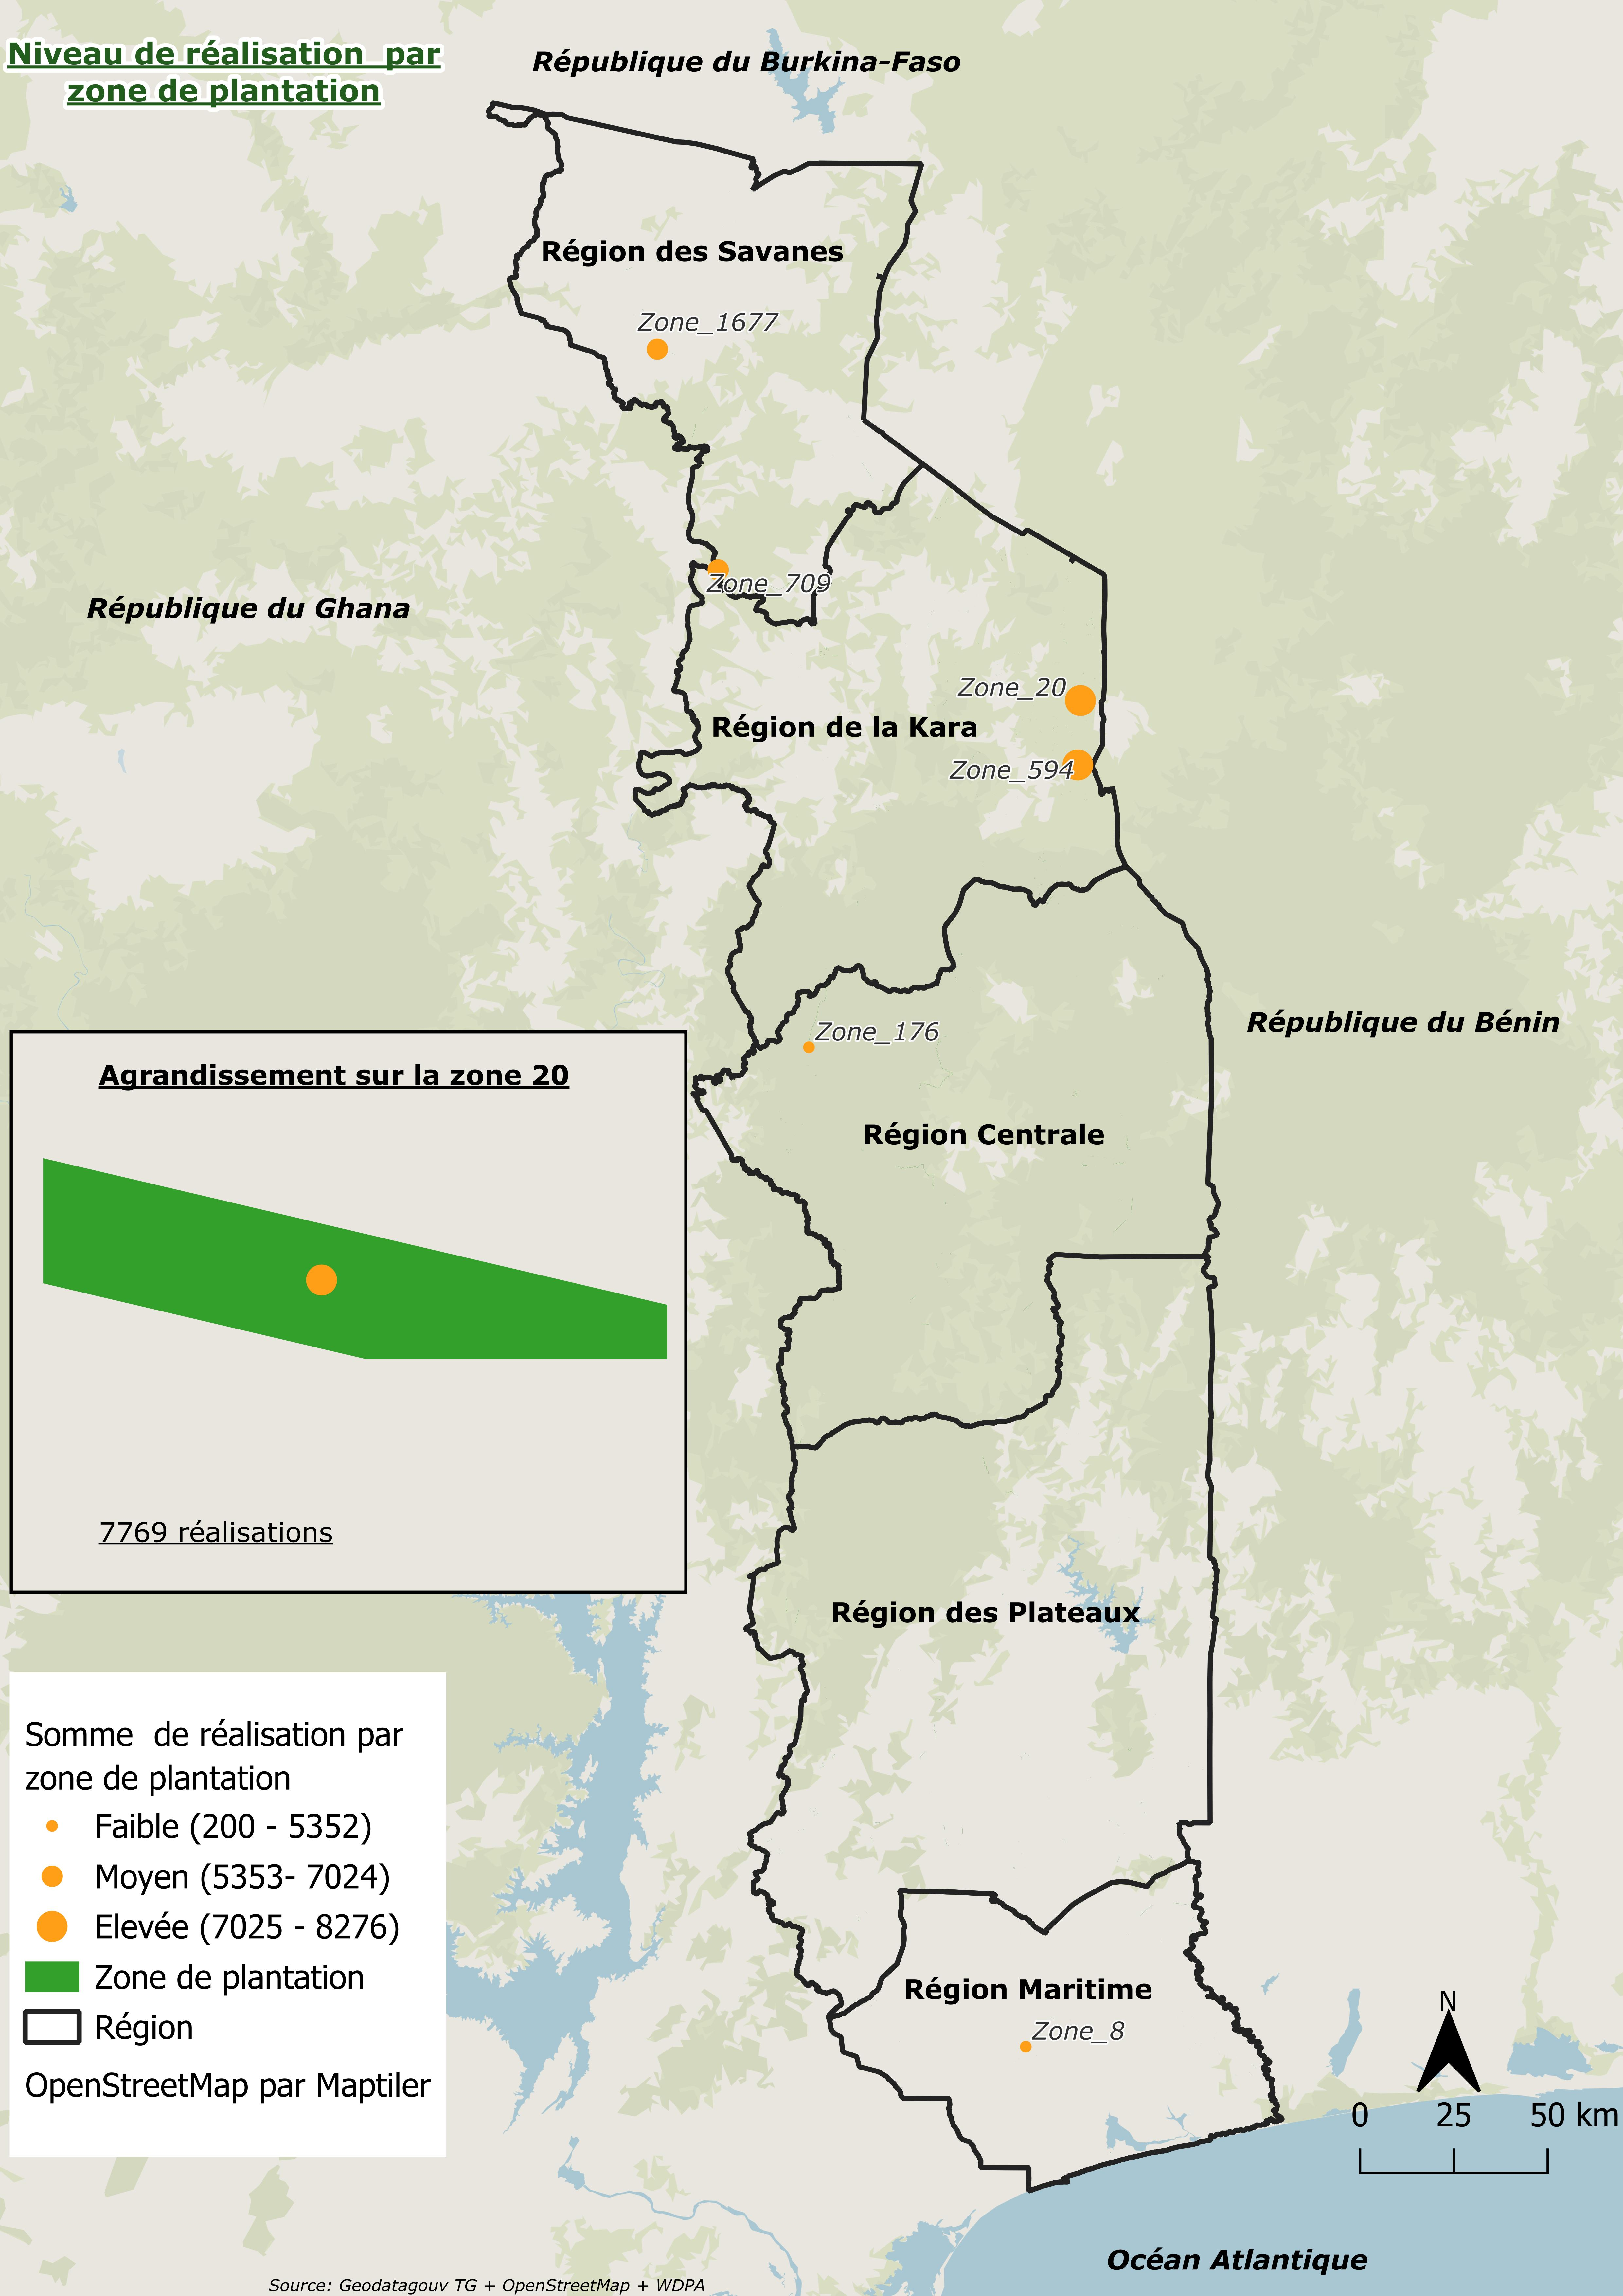

### Annexes

##### Annexe 1 : Les requêtes SQL ayant permis de structurer la base et d'insérer les données

In [ ]:

--Déclarer la clé primaire de la table  region
ALTER TABLE region
ADD CONSTRAINT pk_region PRIMARY KEY (idregion);

-- commune → region
--- ajout des clés primaires de région dans commune 
ALTER TABLE commune ADD COLUMN idregion INTEGER;

UPDATE commune c
SET idregion = r.idregion
FROM region r
WHERE ST_Intersects(c.geom, r.geom);
---- add pk chez commune
ALTER TABLE commune
ADD CONSTRAINT pk_commune PRIMARY KEY (idcommune);

---- id region entant que fk chez commune
ALTER TABLE commune ALTER COLUMN idregion SET NOT NULL;
ALTER TABLE commune
ADD CONSTRAINT fk_commune_region
FOREIGN KEY (idregion)
REFERENCES region(idregion);

-------- add idlocalite as pk
ALTER TABLE localite
ADD CONSTRAINT pk_localite PRIMARY KEY (idlocalite);

---- detecter les corresspondance localité - commune
ALTER TABLE localite ADD COLUMN idcommune INTEGER;

UPDATE localite l
SET idcommune = c.idcommune
FROM commune c
WHERE ST_Within(l.geom, c.geom);

---- idcommune en tant que fk chez localite
ALTER TABLE localite ALTER COLUMN idcommune SET NOT NULL;
ALTER TABLE localite
ADD CONSTRAINT fk_localite_commune
FOREIGN KEY (idcommune)
REFERENCES commune(idcommune);

---- add idap as pk de aire_protege
ALTER TABLE aire_protege
ADD CONSTRAINT pk_ap PRIMARY KEY (idap);

--- ajout de pk  chez la table se_trouver-- subtilité-deux table en clé primaire
ALTER TABLE se_trouver
ADD CONSTRAINT pk_se_trouver
PRIMARY KEY (idap, idlocalite);
-- insertion de la relation spatiale afin de remplir les  tables de clés primaires
INSERT INTO se_trouver (idap, idlocalite)
SELECT
    ap.idap,
    l.idlocalite
FROM aire_protege ap
JOIN localite l
ON ST_Contains(ap.geom, l.geom);
-- declaration des foreign key de la table se_trouver
--- les pk chez la table se_trouver etant de type varchar il faut les convertir d'abord en int
ALTER TABLE se_trouver
ALTER COLUMN idap TYPE INTEGER
USING idap::INTEGER;

ALTER TABLE se_trouver
ALTER COLUMN idlocalite TYPE INTEGER
USING idlocalite::INTEGER;

---- vers aire_protege

ALTER TABLE se_trouver
ADD CONSTRAINT fk_se_trouver_aire
FOREIGN KEY (idap)
REFERENCES aire_protege(idap);

----- vers  localite
ALTER TABLE se_trouver
ADD CONSTRAINT fk_se_trouver_localite
FOREIGN KEY (idlocalite)
REFERENCES localite(idlocalite);

---declaration de la clé primaire de la table sitearestaurer
ALTER TABLE sitearestaurer
ADD CONSTRAINT pk_site
PRIMARY KEY (idsite);

-- déclaration des clés primaires de la table rattacher
ALTER TABLE rattacher
ADD CONSTRAINT 	pk_rattacher
PRIMARY KEY (idsite, idlocalite);
--- remplir les champs idsite et idlocalite de la table rattacher à l'aide de la  relation spaiale de locaite et siterestaurer
INSERT INTO rattacher (idsite, idlocalite)
SELECT
    s.idsite,
    l.idlocalite
FROM sitearestaurer s
JOIN localite l
ON ST_Contains(s.geom, l.geom);

--- les pk chez la table rattacher étant de type varchar il faut les convertir d'abord en int
ALTER TABLE rattacher
ALTER COLUMN idsite TYPE INTEGER
USING idsite::INTEGER;

ALTER TABLE rattacher
ALTER COLUMN idlocalite TYPE INTEGER
USING idlocalite::INTEGER;

--- déclaration des fk de rattacher
-- vers localite
ALTER TABLE rattacher
ADD CONSTRAINT fk_rattacher_localite
FOREIGN KEY (idlocalite)
REFERENCES localite(idlocalite);

---vers sitearestaurer
ALTER TABLE rattacher
ADD CONSTRAINT fk_rattacher_sitearestaurer
FOREIGN KEY (idsite)
REFERENCES sitearestaurer(idsite);

-------- ajout de pk de zoneplantation
ALTER TABLE zoneplantation
ADD CONSTRAINT pk_idzone
PRIMARY KEY (idzone);

---- ajout de idsite dans zoneplantation
ALTER TABLE zoneplantation ADD COLUMN idsite INTEGER;

UPDATE zoneplantation z
SET idsite = s.idsite
FROM sitearestaurer s
WHERE ST_Within(ST_PointOnSurface(z.geom), s.geom);

------- ajout de la colonne idsite  chez zone planatation en tant que FK 
ALTER TABLE zoneplantation ALTER COLUMN idsite SET NOT NULL;
ALTER TABLE zoneplantation
ADD CONSTRAINT fk_zoneplantation_site
FOREIGN KEY (idsite)
REFERENCES sitearestaurer(idsite);

--- déclaration  de la PK de la table indicateur
ALTER TABLE indicateur
ADD CONSTRAINT pk_indicateur
PRIMARY KEY (idindic);

---- déclaration de la PK de la table baseline
ALTER TABLE baseline
ADD CONSTRAINT pk_baseline
PRIMARY KEY (idbaseline);

--- Déclaration de la FK de la table baseline vers table indicateur
---- changer le champ idindic de indicateur en INT dans un 1er temps
ALTER TABLE indicateur
ALTER COLUMN idindic TYPE INTEGER
USING idindic::INTEGER;

---- changer le champ idindic de baseline en INT dans un 1er temps
ALTER TABLE baseline
ALTER COLUMN idindic TYPE INTEGER
USING idindic::INTEGER;

-- etape proprement dite
ALTER TABLE baseline ALTER COLUMN idindic SET NOT NULL;
ALTER TABLE baseline
ADD CONSTRAINT fk_baseline_indic
FOREIGN KEY (idindic)
REFERENCES indicateur(idindic);

---- Déclaration de la FK de la table baseline vers table sitearestaurer
---- changer le champ idsite de baseline en INT dans un 1er temps
ALTER TABLE baseline
ALTER COLUMN idsite TYPE INTEGER
USING idsite::INTEGER;

---- Etape de déclaration proprement dite
ALTER TABLE baseline ALTER COLUMN idsite SET NOT NULL;
ALTER TABLE baseline
ADD CONSTRAINT fk_baseline_site
FOREIGN KEY (idsite)
REFERENCES sitearestaurer(idsite);

---- déclaration de la PK de la table cible
ALTER TABLE cible
ADD CONSTRAINT pk_cible
PRIMARY KEY (idcible);

---- Déclaration de la FK de la table cible vers table sitearestaurer
---- changer le champ idsite de cible en INT dans un 1er temps
ALTER TABLE cible
ALTER COLUMN idsite TYPE INTEGER
USING idsite::INTEGER;

---- Etape de déclaration proprement dite
ALTER TABLE cible ALTER COLUMN idsite SET NOT NULL;
ALTER TABLE cible
ADD CONSTRAINT fk_cible_site
FOREIGN KEY (idsite)
REFERENCES sitearestaurer(idsite);

---- Déclaration de la FK de la table cible vers table sitearestaurer
---- changer le champ idindic de cible en INT dans un 1er temps
ALTER TABLE cible
ALTER COLUMN idindic TYPE INTEGER
USING idindic::INTEGER;

---- Etape de déclaration proprement dite
ALTER TABLE cible ALTER COLUMN idindic SET NOT NULL;
ALTER TABLE cible
ADD CONSTRAINT fk_cible_indic
FOREIGN KEY (idindic)
REFERENCES indicateur(idindic);

--- Declaration de la clé primaire de la table typeactivite
---- changer le champ idtacti de cible en INT dans un 1er temps
ALTER TABLE typeactivite
ALTER COLUMN idtacti TYPE INTEGER
USING idtacti::INTEGER;

--- Déclaration proprement dite
ALTER TABLE typeactivite
ADD CONSTRAINT pk_typeactivite
PRIMARY KEY (idtacti)



--- Declaration de la clé primaire de la table acteur
---- changer le champ idtacti de cible en INT dans un 1er temps
ALTER TABLE acteur
ALTER COLUMN idacteur TYPE INTEGER
USING idacteur::INTEGER;

--- Déclaration proprement dite
ALTER TABLE acteur
ADD CONSTRAINT pk_acteur
PRIMARY KEY (idacteur)


--- Déclaration de la PK de réalisation
---- changer le champ idrealisation de realisation en INT dans un 1er temps
ALTER TABLE realisation
ALTER COLUMN idrealisation TYPE INTEGER
USING idrealisation::INTEGER;

--- Déclaration proprement dite
ALTER TABLE realisation
ADD CONSTRAINT pk_realisation
PRIMARY KEY (idrealisation)

-- déclaration des  FK de réalisation
-- déclaration de idindic vers table indicateur
---- changer le champ idindic de realisation en INT dans un 1er temps
ALTER TABLE realisation
ALTER COLUMN idindic TYPE INTEGER
USING idindic::INTEGER;

---- Etape de déclaration proprement dite de idindic
ALTER TABLE realisation ALTER COLUMN idindic SET NOT NULL;
ALTER TABLE realisation
ADD CONSTRAINT fk_realisation_indic
FOREIGN KEY (idindic)
REFERENCES indicateur(idindic);

--- declaration vers table zoneplantation
---- changer le champ idzone de realisation en INT dans un 1er temps
ALTER TABLE realisation
ALTER COLUMN idzone TYPE INTEGER
USING idzone::INTEGER;


---- Etape de déclaration proprement dite de idindic

ALTER TABLE realisation ALTER COLUMN idzone SET NOT NULL;
ALTER TABLE realisation
ADD CONSTRAINT fk_realisation_idzone
FOREIGN KEY (idzone)
REFERENCES zoneplantation(idzone);

--- declaration vers table typeactivite
---- changer le champ idtacti de realisation en INT dans un 1er temps
ALTER TABLE realisation
ALTER COLUMN idtacti TYPE INTEGER
USING idtacti::INTEGER;

---- Etape de déclaration proprement dite de idindic
ALTER TABLE realisation ALTER COLUMN idtacti SET NOT NULL;
ALTER TABLE realisation
ADD CONSTRAINT fk_realisation_typeacti
FOREIGN KEY (idtacti)
REFERENCES typeactivite(idtacti);

--- declaration des PK de la table effectuer
---- changer les champs idacteur et idrealisation  en INT dans un 1er temps
ALTER TABLE effectuer
ALTER COLUMN idacteur TYPE INTEGER
USING idacteur::INTEGER;

ALTER TABLE effectuer
ALTER COLUMN idrealisation TYPE INTEGER
USING idrealisation::INTEGER;

-- declaration de idrealisation et de idacteur comme clés primaires
ALTER TABLE effectuer
ADD CONSTRAINT pk_effectuer
PRIMARY KEY (idacteur,idrealisation)

--- declaration des FK de la table effectuer

--- vers la table acteur

--- declaration  de FK proprement dite

ALTER TABLE effectuer ALTER COLUMN idacteur SET NOT NULL;
ALTER TABLE effectuer
ADD CONSTRAINT fk_effectuer_acteur
FOREIGN KEY (idacteur)
REFERENCES acteur(idacteur);

--- vers la table  realisation

--FK proprement dit
ALTER TABLE effectuer ALTER COLUMN idrealisation SET NOT NULL;
ALTER TABLE effectuer
ADD CONSTRAINT fk_effectuer_realisation
FOREIGN KEY (idrealisation)
REFERENCES realisation(idrealisation);


--- declaration de PK la table entretien
---- changer le champ identretien de entretien en INT dans un 1er temps
ALTER TABLE entretien
ALTER COLUMN identretien TYPE INTEGER
USING identretien::INTEGER;

---- Etape de déclaration proprement dite de identretien
ALTER TABLE entretien
ADD CONSTRAINT pk_entretien
PRIMARY KEY (identretien)

--FK idtacti preoprement dit
--changer type de idtacti dans entretien
ALTER TABLE entretien
ALTER COLUMN idtacti TYPE INTEGER
USING idtacti::INTEGER;

ALTER TABLE entretien ALTER COLUMN idtacti SET NOT NULL;
ALTER TABLE entretien
ADD CONSTRAINT fk_entretien_typeacti
FOREIGN KEY (idtacti)
REFERENCES typeactivite(idtacti);


--- declaration de PK la table plantation
---- changer le champ identretien de entretien en INT dans un 1er temps
ALTER TABLE plantation
ALTER COLUMN idplantation TYPE INTEGER
USING idplantation::INTEGER;

---- Etape de déclaration proprement dite de identretien
ALTER TABLE plantation
ADD CONSTRAINT pk_plantation
PRIMARY KEY (idplantation)

--FK idtacti preoprement dit chez plantation
--changer type de idtacti dans entretien
ALTER TABLE plantation
ALTER COLUMN idtacti TYPE INTEGER
USING idtacti::INTEGER;

ALTER TABLE plantation ALTER COLUMN idtacti SET NOT NULL;
ALTER TABLE plantation
ADD CONSTRAINT fk_plantation_typeacti
FOREIGN KEY (idtacti)
REFERENCES typeactivite(idtacti);


--- declaration de PK la tbale sensibilisation
---- changer le champ idsens de sensibilisation en INT dans un 1er temps
ALTER TABLE sensibilisation
ALTER COLUMN idsens TYPE INTEGER
USING idsens::INTEGER;

---- Etape de déclaration proprement dite de idsens
ALTER TABLE sensibilisation
ADD CONSTRAINT pk_sensibilisation
PRIMARY KEY (idsens)

--FK idtacti proprement dit vers typeactivite
--changer type de idtacti dans sensibilisation
ALTER TABLE sensibilisation
ALTER COLUMN idtacti TYPE INTEGER
USING idtacti::INTEGER;

ALTER TABLE sensibilisation ALTER COLUMN idtacti SET NOT NULL;
ALTER TABLE sensibilisation
ADD CONSTRAINT fk_sensibilisation_typeacti
FOREIGN KEY (idtacti)
REFERENCES typeactivite(idtacti);

--FK idlocalite proprement dit vers localite
--changer type de idlocalite dans sensibilisation
ALTER TABLE sensibilisation
ALTER COLUMN idlocalite TYPE INTEGER
USING idlocalite::INTEGER;

ALTER TABLE sensibilisation ALTER COLUMN idlocalite SET NOT NULL;
ALTER TABLE sensibilisation
ADD CONSTRAINT fk_sensibilisation_localite
FOREIGN KEY (idlocalite)
REFERENCES localite(idlocalite);

--- Declaration de la clé primaire de la table espece
---- changer le champ idespece de espece en INT dans un 1er temps
ALTER TABLE espece
ALTER COLUMN idespece TYPE INTEGER
USING idespece::INTEGER;

--- Déclaration proprement dite
ALTER TABLE espece
ADD CONSTRAINT pk_espece
PRIMARY KEY (idespece)



--- declaration de PK la table utiliser
---- changer les champs id de utiliser en INT dans un 1er temps
ALTER TABLE utiliser
ALTER COLUMN idplantation TYPE INTEGER
USING idplantation::INTEGER;

ALTER TABLE utiliser
ALTER COLUMN idespece TYPE INTEGER
USING idespece::INTEGER;

---- Etape de déclaration proprement dite de PK
ALTER TABLE utiliser
ADD CONSTRAINT pk_utiliser
PRIMARY KEY (idplantation,idespece)

--FK idplantation proprement dit vers plantation
--changer type de idplantation dans utiliser
ALTER TABLE utiliser
ALTER COLUMN idplantation TYPE INTEGER
USING idplantation::INTEGER;

ALTER TABLE utiliser ALTER COLUMN idplantation SET NOT NULL;
ALTER TABLE utiliser
ADD CONSTRAINT fk_utiliser_plantation
FOREIGN KEY (idplantation)
REFERENCES plantation(idplantation);

--FK idespece proprement dit vers espece
--changer type de idespece dans utiliser
ALTER TABLE utiliser
ALTER COLUMN idespece TYPE INTEGER
USING idespece::INTEGER;

--- FK idespece chez utiliser
ALTER TABLE utiliser ALTER COLUMN idespece SET NOT NULL;
ALTER TABLE utiliser
ADD CONSTRAINT fk_utiliser_espece
FOREIGN KEY (idespece)
REFERENCES espece(idespece);

---- création des index spatiaux sur les couches spatiales uniquement bien evidemment
--sur la couche commune
CREATE INDEX idx_commune_geom
ON commune
USING GIST (geom);

--sur la couche région

CREATE INDEX idx_region_geom
ON region
USING GIST (geom);

--sur la couche zoneplantation

CREATE INDEX idx_zoneplantation_geom
ON zoneplantation
USING GIST (geom);

--sur la couche sitearestaurer

CREATE INDEX idx_sitearestaurer_geom
ON sitearestaurer
USING GIST (geom);

-- sur la couche localite

CREATE INDEX idx_localite_geom
ON localite
USING GIST (geom);

--sur la couche aire_protege

CREATE INDEX idx_aire_protege_geom
ON aire_protege
USING GIST (geom);

##### Annexe 2 : Source de données 

Les couches  région, communes, localités, aires protégées sont téléchargé sur le site [GéodatagouvTG.](https://geodata.gouv.tg/donnees)

La couche zone de plantation est un périmètre  de 30 mètre autour des aires protégées. Elle est donc généré par moi même.
Les autres couches de cette base de donnée sont générés via un script python vu que les données que doivent ne sont pas disponible en format csv ou équivalent. Le script python est disponible via [ce lien](https://github.com/Ezechiel18/Portolio_ezechiel/blob/main/Observatoire%20de%20suivi%20des%20activit%C3%A9s%20de%20restauration%20foresti%C3%A8re/Script/generation_couche_observatoire.py) .

Néanmoins la génération de ce script est guidée par la documentation trouvée sur [cette page](https://environnement.gouv.tg/documentation/)

##### Annexe 3: Modèle conceptuel de données

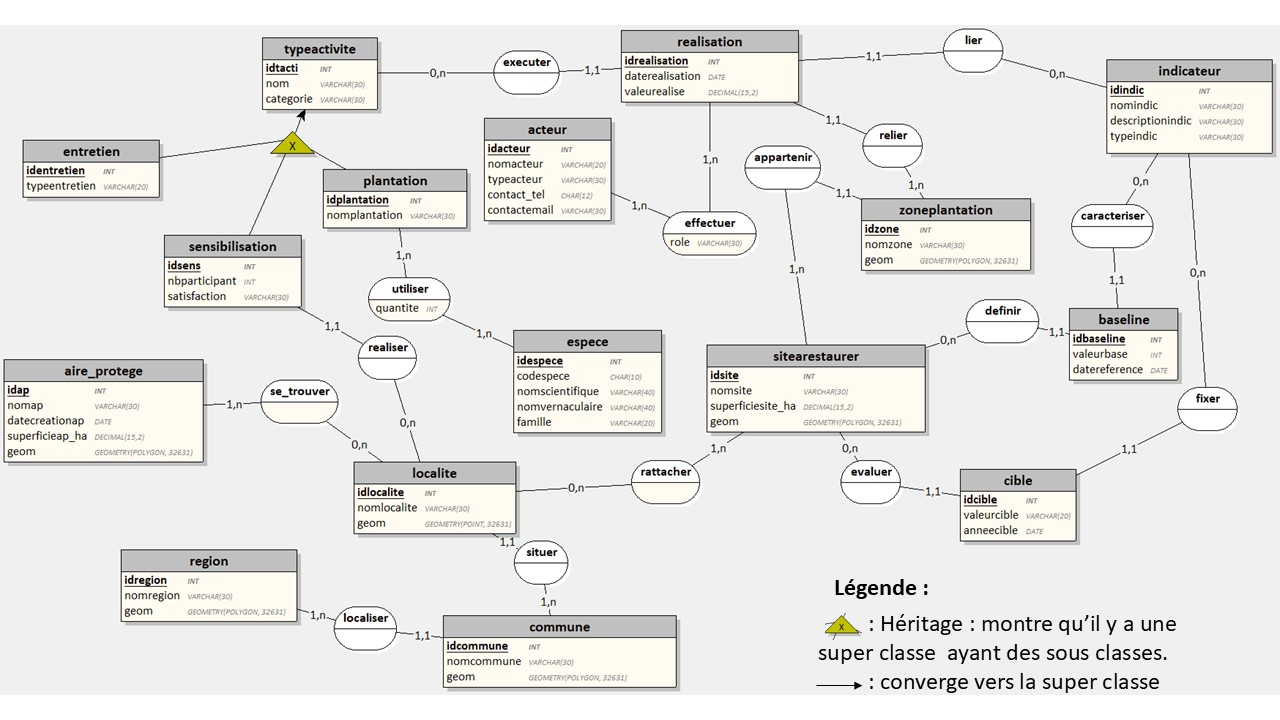

##### Annexe 4: Modèle logique de données

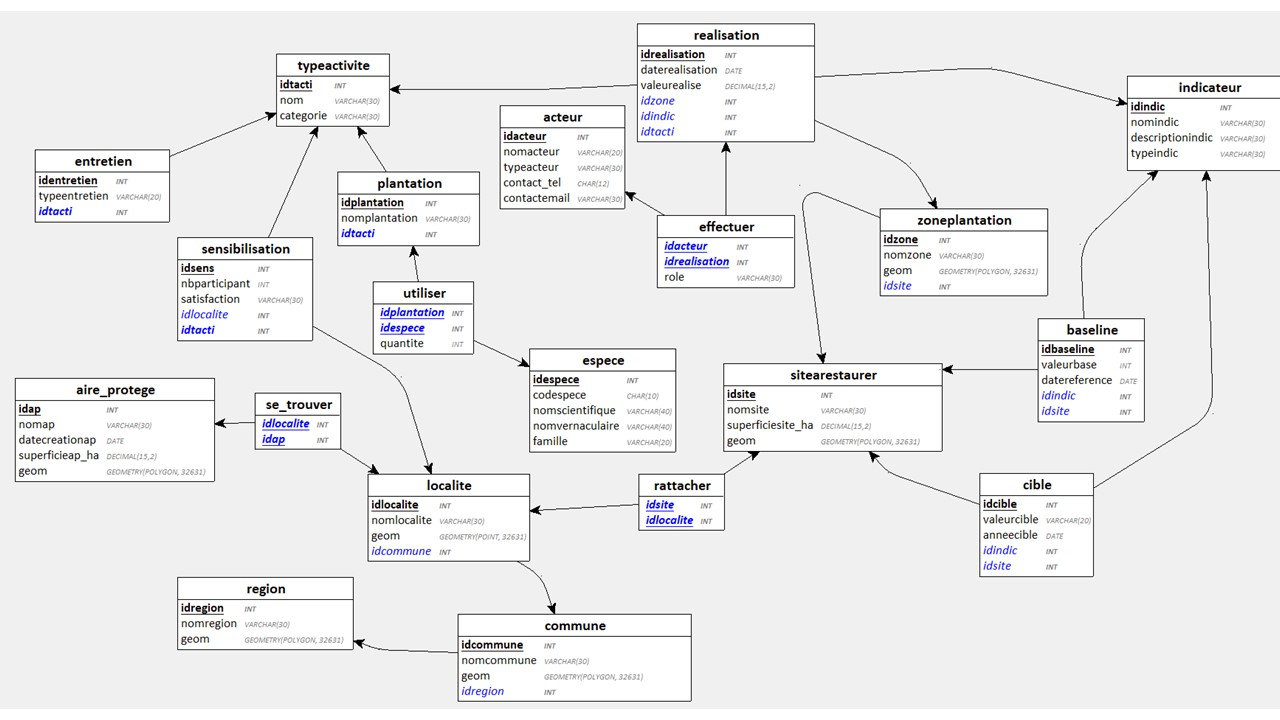

##### Annexe 5: Reproductibilité - Dump

Pour la reproductibilité de cette base de donnée, le fichier dump nommé <b> dump_ametovena.backup </b> sera joint lors de l'envoie.